In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import gc

FOLDER_PATH = Path('/content/drive/My Drive/ECON_833/')

In [3]:
print(FOLDER_PATH.exists())

True


In [4]:
csv_path = FOLDER_PATH / 'biden.csv'
df = pd.read_csv(csv_path, low_memory=False)
df.head()

,biden,female,age,educ,dem,rep
0,90,0,19,12,1,0
1,70,1,51,14,1,0
2,60,0,27,14,0,0
3,50,1,43,14,1,0
4,60,1,38,14,0,1


Question 1

In [5]:
# train/test split (70/30) with random_state = 25
from sklearn.model_selection import train_test_split
X = df[['female','age','dem','rep','educ']].copy()
y = df['biden'].astype(float).copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=25)


In [6]:
# fitting decision tree (recursive binary splitting)
from sklearn.tree import DecisionTreeRegressor
tree = DecisionTreeRegressor(max_depth=3, min_samples_leaf=5, random_state=25)
tree.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=3, min_samples_leaf=5, random_state=25)

In [7]:
# MSE
from sklearn.metrics import mean_squared_error
y_pred = tree.predict(X_test)
test_mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {test_mse:.4f}")

Test MSE: 396.1937


1.1. Interpretation of the result:
1.2. The test MSE is 396.1937.

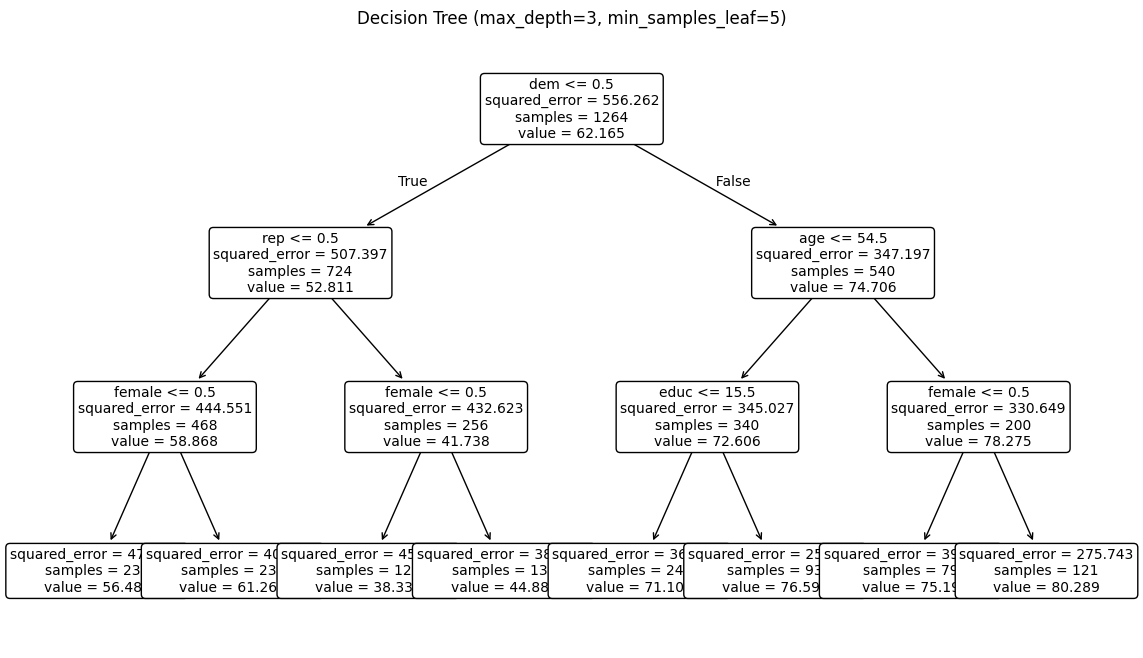

In [8]:
# plotting the tree
import matplotlib.pyplot as plt
from sklearn import tree as sktree
plt.figure(figsize=(14, 8))
sktree.plot_tree(tree, feature_names=X.columns.tolist(), rounded=True, fontsize=10)
plt.title("Decision Tree (max_depth=3, min_samples_leaf=5)")
plt.show()

In [9]:
# text summary and feature importance (not asked just for interpretation purpose)
from sklearn.tree import export_text
print(export_text(tree, feature_names=list(X.columns)))
imp = pd.Series(tree.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nfeature importances:\n", imp)

|--- dem <= 0.50
|   |--- rep <= 0.50
|   |   |--- female <= 0.50
|   |   |   |--- value: [56.49]
|   |   |--- female >  0.50
|   |   |   |--- value: [61.27]
|   |--- rep >  0.50
|   |   |--- female <= 0.50
|   |   |   |--- value: [38.33]
|   |   |--- female >  0.50
|   |   |   |--- value: [44.89]
|--- dem >  0.50
|   |--- age <= 54.50
|   |   |--- educ <= 15.50
|   |   |   |--- value: [71.11]
|   |   |--- educ >  15.50
|   |   |   |--- value: [76.59]
|   |--- age >  54.50
|   |   |--- female <= 0.50
|   |   |   |--- value: [75.19]
|   |   |--- female >  0.50
|   |   |   |--- value: [80.29]


feature importances:
 dem       0.707531
rep       0.231687
female    0.031767
age       0.019312
educ      0.009703
dtype: float64


Question 2

In [10]:
# randomized search CV
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint as sp_randint

# followed the PS 7 question instruction
param_dist = {"max_depth": [3, 10], "min_samples_split": sp_randint(2, 20), "min_samples_leaf":  sp_randint(2, 20)}
base_tree = DecisionTreeRegressor(random_state=25)

rsearch = RandomizedSearchCV(estimator=base_tree, param_distributions=param_dist, n_iter=100, scoring='neg_mean_squared_error', n_jobs=-1, cv=5, random_state=25, return_train_score=False
)
rsearch.fit(X_train, y_train)

best_params = rsearch.best_params_
best_cv_neg_mse = rsearch.best_score_ # negative MSE = def for the scoring
best_cv_mse = -best_cv_neg_mse # (-) to (+)
print("best hyperparameters:", best_params)
print(f"best 5-fold CV MSE (positive): {best_cv_mse:.6f}")

# test MSE of the tuned model (compare with Q1)
best_model = rsearch.best_estimator_
test_mse_opt = mean_squared_error(y_test, best_model.predict(X_test))
print(f"test MSE of tuned: {test_mse_opt:.6f}")

# peek at top 5 CV results
cvres = pd.DataFrame(rsearch.cv_results_)
cols = ["rank_test_score","mean_test_score","param_max_depth","param_min_samples_split","param_min_samples_leaf"]
print("\nTop CV configurations:")
print(cvres[cols].sort_values("rank_test_score").head(5).to_string(index=False))


best hyperparameters: {'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 9}
best 5-fold CV MSE (positive): 404.709941
test MSE of tuned: 394.762000

Top CV configurations:
 rank_test_score  mean_test_score  param_max_depth  param_min_samples_split  param_min_samples_leaf
               1      -404.709941                3                        2                       2
               1      -404.709941                3                       15                       2
               1      -404.709941                3                        9                       2
               1      -404.709941                3                       16                       2
               5      -405.304635                3                        9                       6


Question 3

In [11]:
from sklearn.ensemble import RandomForestRegressor
param_dist = {"n_estimators": [10, 200], "max_depth": [3, 10], "min_samples_split": sp_randint(2, 20), "min_samples_leaf": sp_randint(2, 20), "max_features": sp_randint(1, 5)}

rf = RandomForestRegressor(random_state=25, n_jobs=-1)

rsearch_rf = RandomizedSearchCV(estimator=rf, param_distributions=param_dist, n_iter=100, scoring='neg_mean_squared_error', n_jobs=-1, cv=5, random_state=25, return_train_score=False)
rsearch_rf.fit(X_train, y_train)

best_params = rsearch_rf.best_params_
best_cv_mse = -rsearch_rf.best_score_  # convert to (+)
test_mse = mean_squared_error(y_test, rsearch_rf.best_estimator_.predict(X_test))

print(best_params)
print(f"best 5-fold CV MSE (positive): {best_cv_mse:.6f}")
print(f"test MSE: {test_mse:.6f}")


{'max_depth': 3, 'max_features': 3, 'min_samples_leaf': 19, 'min_samples_split': 2, 'n_estimators': 200}
best 5-fold CV MSE (positive): 398.201401
test MSE: 391.552606
